In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import duckdb

In [2]:
plt.style.use('ggplot')
sns.set(font_scale=1.2)

In [3]:
conn = duckdb.connect(database='/workspaces/txwc/tx_workers_comp.db', read_only=False)

In [ ]:
def load_data(schema="raw"):
    detail_current = pl.from_pandas(conn.execute('select * from raw.pharmacy_detail_current').fetchdf())
    detail_historical = pl.from_pandas(conn.execute('select * from raw.pharmacy_detail_historical').fetchdf())
    header_current = pl.from_pandas(conn.execute('select * from raw.pharmacy_header_current').fetchdf())
    header_historical = pl.from_pandas(conn.execute('select * from raw.pharmacy_header_historical').fetchdf())
    
    # Combine current and historical data
    detail_data = pl.concat([detail_current, detail_historical], how="diagonal")
    header_data = pl.concat([header_current, header_historical], how="diagonal")
    
    # Convert date columns to datetime
    for df in [detail_data, header_data]:
        date_cols = [col for col in df.columns if 'date' in col.lower()]
        for col in date_cols:
            try:
                df = df.with_columns(
                    pl.col(col).cast(pl.Datetime, strict=False).alias(col)
                )
            except:
                pass
    
    numeric_cols = ['drugs_supplies_billed_amount', 'total_amount_paid_per_line', 
                    'drugs_supplies_quantity', 'bill_id']
    
    for col in numeric_cols:
        if col in detail_data.columns:
            detail_data = detail_data.with_columns(
                pl.col(col).cast(pl.Float64, strict=False).alias(col)
            )
    
    return detail_data, header_data

detail_data, header_data = load_data()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pharmacy detail records: 1850000
Pharmacy header records: 1850000


/tmp/ipykernel_7319/450730472.py:13: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias('count'))


Top 10 Most Frequently Prescribed Medications:
shape: (10, 6)
┌──────────────────────────┬───────┬────────────┬──────────────┬────────────────┬──────────────────┐
│ drug_name                ┆ count ┆ total_cost ┆ average_cost ┆ total_quantity ┆ average_quantity │
│ ---                      ┆ ---   ┆ ---        ┆ ---          ┆ ---            ┆ ---              │
│ str                      ┆ u32   ┆ f64        ┆ f64          ┆ f64            ┆ f64              │
╞══════════════════════════╪═══════╪════════════╪══════════════╪════════════════╪══════════════════╡
│ HYDROCODONE/ACETAMINOPHE ┆ 71579 ┆ 4.5323e6   ┆ 63.318963    ┆ 5.9371292e7    ┆ 829.451264       │
│ N                        ┆       ┆            ┆              ┆                ┆                  │
│ IBUPROFEN                ┆ 52232 ┆ 2.0029e6   ┆ 38.346128    ┆ 1.0126837e7    ┆ 193.881854       │
│ GABAPENTIN               ┆ 50370 ┆ 9.1063e6   ┆ 180.787897   ┆ 1.497981e7     ┆ 297.395473       │
│ TRAMADOL HCL             ┆ 

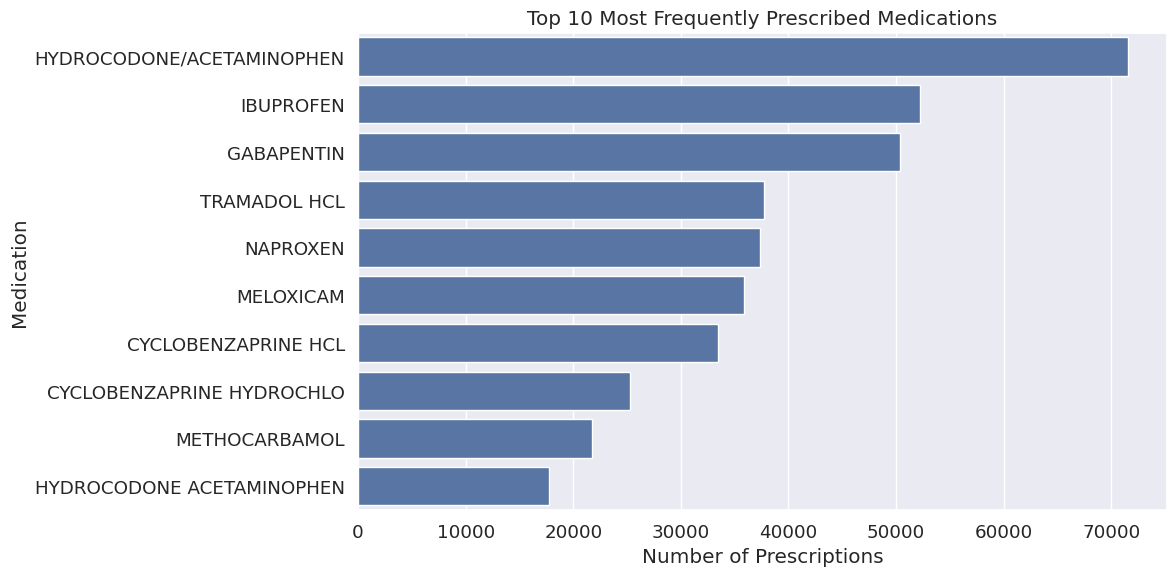

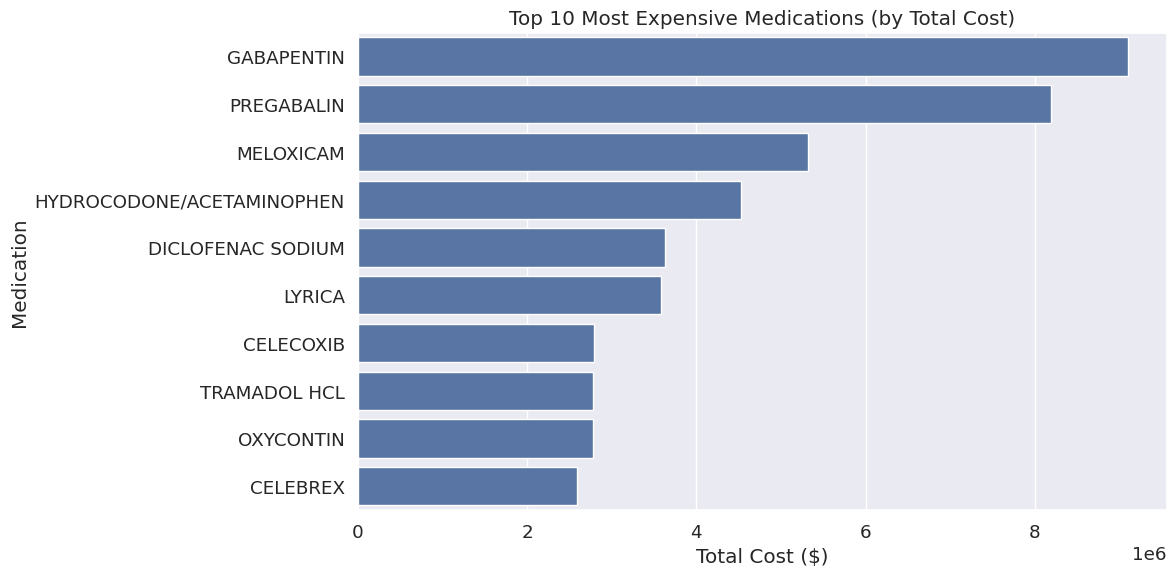

In [ ]:
def analyze_common_medications(detail_data, top_n=10):
    detail_data = detail_data.with_columns([
        pl.col('drugs_supplies_billed_amount').cast(pl.Float64, strict=False),
        pl.col('drugs_supplies_quantity').cast(pl.Float64, strict=False),
        pl.col('total_amount_paid_per_line').cast(pl.Float64, strict=False)
    ])
    
    # Count drug frequency
    drug_counts = (
        detail_data
        .group_by('drug_name')
        .agg(pl.count().alias('count'))
        .sort('count', descending=True)
    )
    
    # Calculate total costs by drug
    drug_costs = (
        detail_data
        .group_by('drug_name')
        .agg([
            pl.col('drugs_supplies_billed_amount').sum().alias('total_cost'),
            pl.col('drugs_supplies_billed_amount').mean().alias('average_cost')
        ])
    )
    
    # Calculate quantities by drug
    drug_quantities = (
        detail_data
        .group_by('drug_name')
        .agg([
            pl.col('drugs_supplies_quantity').sum().alias('total_quantity'),
            pl.col('drugs_supplies_quantity').mean().alias('average_quantity')
        ])
    )
    
    # Merge all drug metrics
    drug_metrics = (
        drug_counts
        .join(drug_costs, on='drug_name')
        .join(drug_quantities, on='drug_name')
        .fill_null(0)
    )
    
    # Get top drugs by frequency
    top_by_frequency = drug_metrics.sort('count', descending=True).head(top_n)
    
    # Get top drugs by total cost
    top_by_cost = drug_metrics.sort('total_cost', descending=True).head(top_n)
    
    # Get top drugs by average cost (with at least 2 prescriptions)
    top_by_avg_cost = (
        drug_metrics
        .filter(pl.col('count') > 1)
        .sort('average_cost', descending=True)
        .head(top_n)
    )
    
    # Print results
    print(f"Top {top_n} Most Frequently Prescribed Medications:")
    print(top_by_frequency)
    print(f"\nTop {top_n} Most Expensive Medications (by Total Cost):")
    print(top_by_cost)
    print(f"\nTop {top_n} Most Expensive Medications (by Average Cost, min 2 prescriptions):")
    print(top_by_avg_cost)
    
    # For plotting, convert to Pandas
    top_by_frequency_pd = top_by_frequency.to_pandas()
    top_by_cost_pd = top_by_cost.to_pandas()
    
    # Plot top medications by frequency
    plt.figure(figsize=(12, 6))
    sns.barplot(x='count', y='drug_name', data=top_by_frequency_pd)
    plt.title(f'Top {top_n} Most Frequently Prescribed Medications')
    plt.xlabel('Number of Prescriptions')
    plt.ylabel('Medication')
    plt.tight_layout()
    plt.show()
    
    # Plot top medications by cost
    plt.figure(figsize=(12, 6))
    sns.barplot(x='total_cost', y='drug_name', data=top_by_cost_pd)
    plt.title(f'Top {top_n} Most Expensive Medications (by Total Cost)')
    plt.xlabel('Total Cost ($)')
    plt.ylabel('Medication')
    plt.tight_layout()
    plt.show()
    
    return drug_metrics

drug_metrics = analyze_common_medications(detail_data)

/tmp/ipykernel_7319/772591853.py:64: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias('count'))


Prescription Timing Analysis:
Early period (0-30 days): 250908 prescriptions
Mid period (31-90 days): 192323 prescriptions
Late period (90+ days): 1406762 prescriptions

Top Drugs in First 30 Days After Injury:
shape: (5, 2)
┌───────────────────────────┬───────┐
│ drug_name                 ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ u32   │
╞═══════════════════════════╪═══════╡
│ IBUPROFEN                 ┆ 17565 │
│ NAPROXEN                  ┆ 13513 │
│ CYCLOBENZAPRINE HCL       ┆ 8394  │
│ CYCLOBENZAPRINE HYDROCHLO ┆ 7635  │
│ HYDROCODONE/ACETAMINOPHEN ┆ 6309  │
└───────────────────────────┴───────┘

Top Drugs 31-90 Days After Injury:
shape: (5, 2)
┌───────────────────────────┬───────┐
│ drug_name                 ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ u32   │
╞═══════════════════════════╪═══════╡
│ IBUPROFEN                 ┆ 9773  │
│ NAPROXEN                  ┆ 7865  │
│ HYDROCODONE/ACETAMINOPHEN ┆ 6839  │
│ M

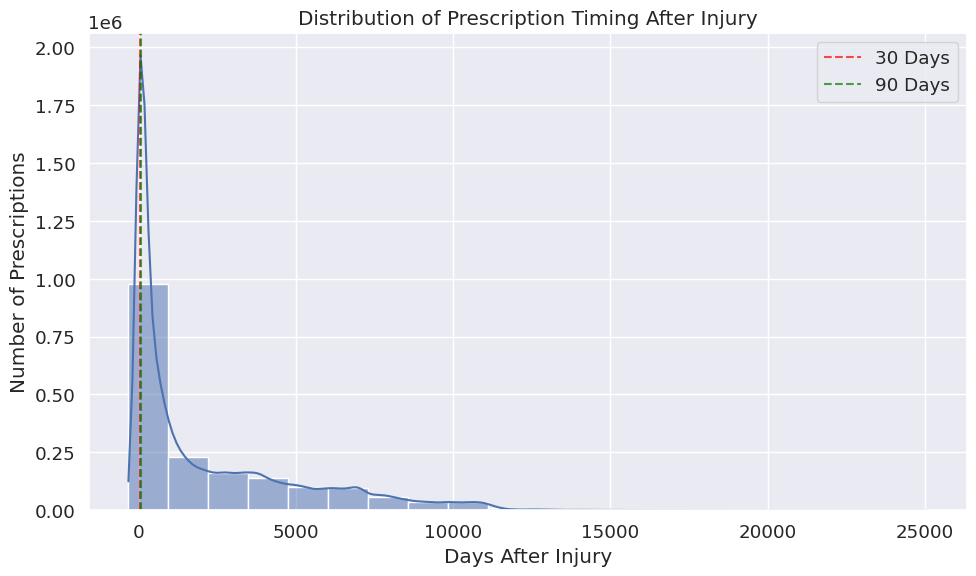

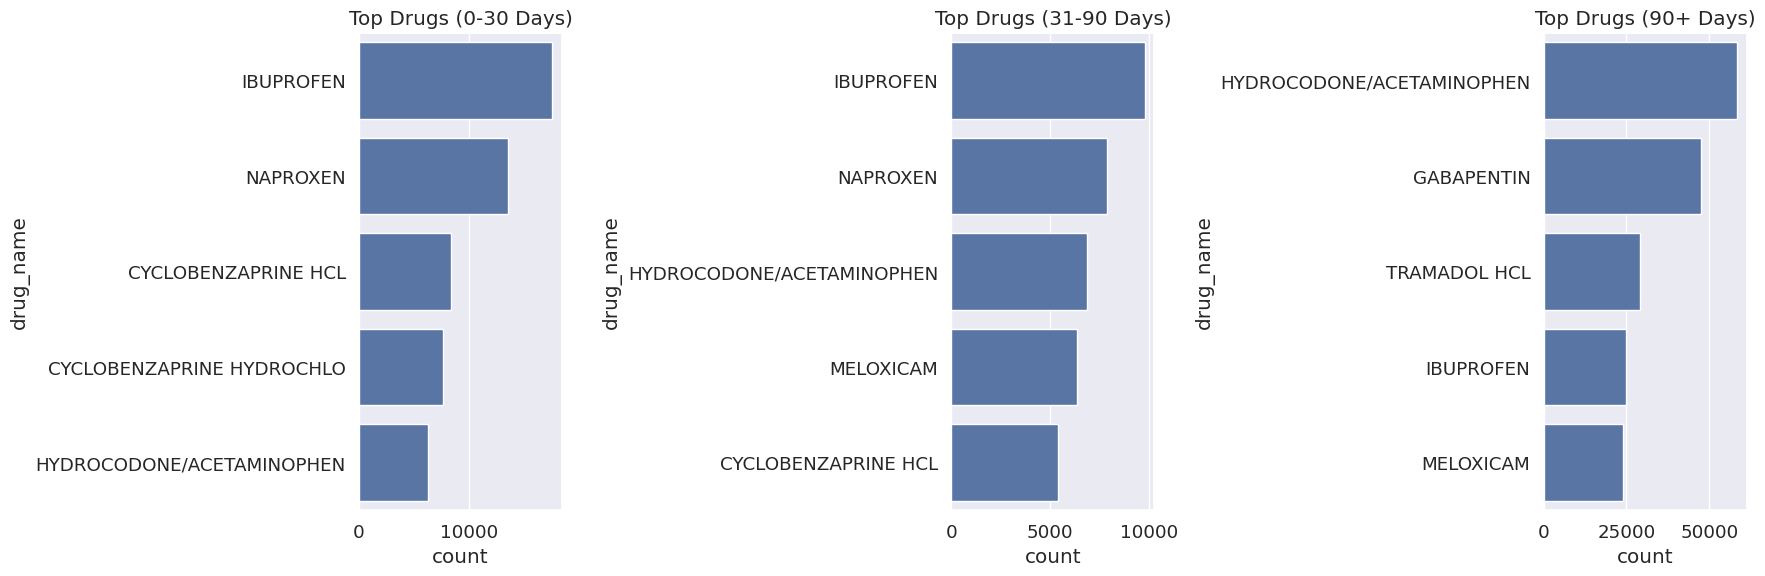

/tmp/ipykernel_7319/772591853.py:133: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias('count'))



Top Drugs for Male Patients:
shape: (5, 2)
┌───────────────────────────┬───────┐
│ drug_name                 ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ u32   │
╞═══════════════════════════╪═══════╡
│ HYDROCODONE/ACETAMINOPHEN ┆ 53046 │
│ GABAPENTIN                ┆ 33838 │
│ IBUPROFEN                 ┆ 31422 │
│ TRAMADOL HCL              ┆ 24484 │
│ NAPROXEN                  ┆ 21279 │
└───────────────────────────┴───────┘

Top Drugs for Female Patients:
shape: (5, 2)
┌───────────────────────────┬───────┐
│ drug_name                 ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ u32   │
╞═══════════════════════════╪═══════╡
│ IBUPROFEN                 ┆ 18567 │
│ HYDROCODONE/ACETAMINOPHEN ┆ 17250 │
│ NAPROXEN                  ┆ 14582 │
│ GABAPENTIN                ┆ 14462 │
│ MELOXICAM                 ┆ 13472 │
└───────────────────────────┴───────┘


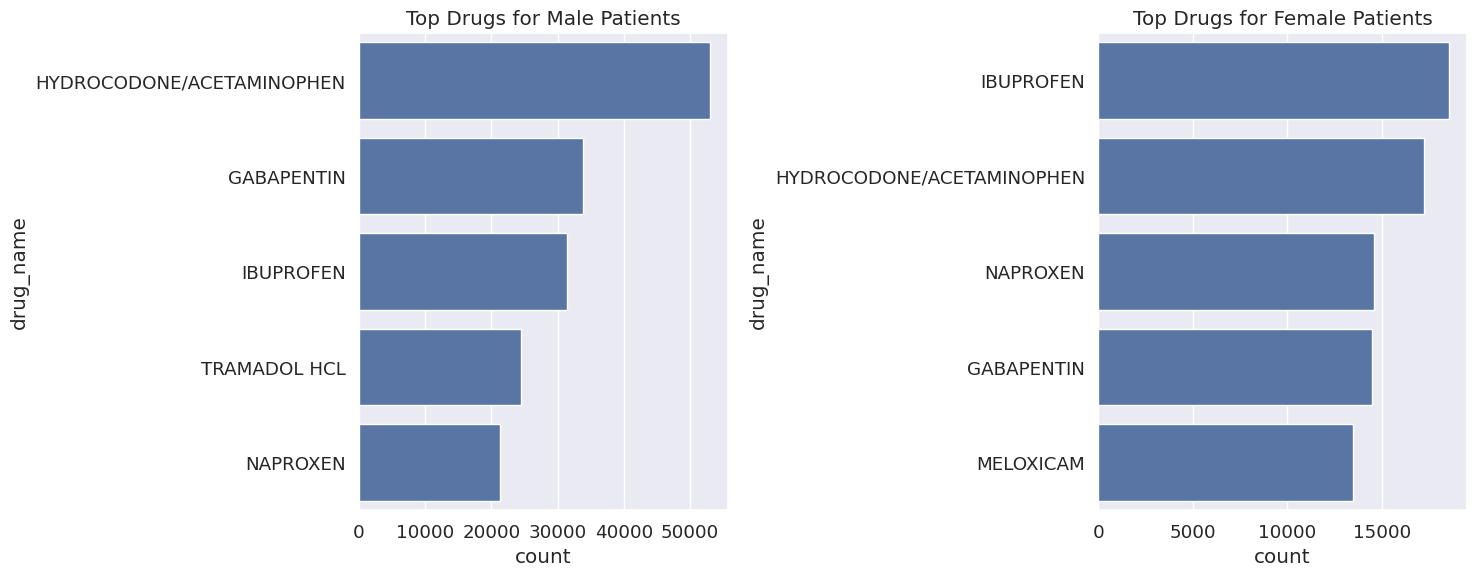

In [ ]:
def analyze_prescription_timing(detail_data, header_data):
    detail_data = detail_data.with_columns([
        pl.col('bill_id').cast(pl.Int64, strict=False),
        pl.col('drugs_supplies_billed_amount').cast(pl.Float64, strict=False),
        pl.col('total_amount_paid_per_line').cast(pl.Float64, strict=False),
        pl.col('drugs_supplies_quantity').cast(pl.Float64, strict=False)
    ])
    
    detail_data = detail_data.with_columns([
        pl.col('prescription_line_date').cast(pl.Datetime, strict=False)
    ])
    
    header_data = header_data.with_columns([
        pl.col('bill_id').cast(pl.Int64, strict=False),
        pl.col('employee_date_of_injury').cast(pl.Datetime, strict=False)
    ])
    
    # Create mappings from header data
    injury_dates = (
        header_data
        .filter(pl.col('employee_date_of_injury').is_not_null())
        .select(['bill_id', 'employee_date_of_injury'])
        .unique()
    )
    
    gender_data = (
        header_data
        .filter(pl.col('employee_gender_code').is_not_null())
        .select(['bill_id', 'employee_gender_code'])
        .unique()
    )
    
    # Join injury date and gender to detail data
    detail_with_info = (
        detail_data
        .join(injury_dates, on='bill_id', how='left')
        .join(gender_data, on='bill_id', how='left')
    )
    
    # Calculate days between injury and prescription
    valid_data = (
        detail_with_info
        .filter(
            pl.col('employee_date_of_injury').is_not_null() & 
            pl.col('prescription_line_date').is_not_null()
        )
        .with_columns([
            ((pl.col('prescription_line_date') - pl.col('employee_date_of_injury')).dt.total_days()).alias('days_after_injury')
        ])
    )
    
    # Define time periods
    early = valid_data.filter((pl.col('days_after_injury') >= 0) & (pl.col('days_after_injury') <= 30))
    mid = valid_data.filter((pl.col('days_after_injury') > 30) & (pl.col('days_after_injury') <= 90))
    late = valid_data.filter(pl.col('days_after_injury') > 90)
    
    # Get top drugs by period
    def get_top_drugs(period_data, top_n=5):
        return (
            period_data
            .group_by('drug_name')
            .agg(pl.count().alias('count'))
            .sort('count', descending=True)
            .head(top_n)
        )
    
    early_top = get_top_drugs(early)
    mid_top = get_top_drugs(mid)
    late_top = get_top_drugs(late)
    
    # Print results
    print("Prescription Timing Analysis:")
    print(f"Early period (0-30 days): {early.height} prescriptions")
    print(f"Mid period (31-90 days): {mid.height} prescriptions")
    print(f"Late period (90+ days): {late.height} prescriptions")
    
    print("\nTop Drugs in First 30 Days After Injury:")
    print(early_top)
    
    print("\nTop Drugs 31-90 Days After Injury:")
    print(mid_top)
    
    print("\nTop Drugs 90+ Days After Injury:")
    print(late_top)
    
    # Convert to pandas for plotting
    valid_data_pd = valid_data.to_pandas()
    early_top_pd = early_top.to_pandas()
    mid_top_pd = mid_top.to_pandas()
    late_top_pd = late_top.to_pandas()
    
    # Plot distribution of days after injury
    plt.figure(figsize=(10, 6))
    sns.histplot(valid_data_pd['days_after_injury'], bins=20, kde=True)
    plt.title('Distribution of Prescription Timing After Injury')
    plt.xlabel('Days After Injury')
    plt.ylabel('Number of Prescriptions')
    plt.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='30 Days')
    plt.axvline(x=90, color='green', linestyle='--', alpha=0.7, label='90 Days')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Plot top drugs by period
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Early period
    if early_top.height > 0:
        sns.barplot(x='count', y='drug_name', data=early_top_pd, ax=axes[0])
        axes[0].set_title('Top Drugs (0-30 Days)')
    
    # Mid period
    if mid_top.height > 0:
        sns.barplot(x='count', y='drug_name', data=mid_top_pd, ax=axes[1])
        axes[1].set_title('Top Drugs (31-90 Days)')
    
    # Late period
    if late_top.height > 0:
        sns.barplot(x='count', y='drug_name', data=late_top_pd, ax=axes[2])
        axes[2].set_title('Top Drugs (90+ Days)')
    
    plt.tight_layout()
    plt.show()
    
    # Gender-based analysis
    def get_gender_drugs(gender_code):
        gender_data = valid_data.filter(pl.col('employee_gender_code') == gender_code)
        return (
            gender_data
            .group_by('drug_name')
            .agg(pl.count().alias('count'))
            .sort('count', descending=True)
            .head(5)
        )
    
    male_top = get_gender_drugs('M')
    female_top = get_gender_drugs('F')
    
    print("\nTop Drugs for Male Patients:")
    print(male_top)
    
    print("\nTop Drugs for Female Patients:")
    print(female_top)
    
    # Convert to pandas for plotting
    male_top_pd = male_top.to_pandas()
    female_top_pd = female_top.to_pandas()
    
    # Plot gender differences
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    if male_top.height > 0:
        sns.barplot(x='count', y='drug_name', data=male_top_pd, ax=axes[0])
        axes[0].set_title('Top Drugs for Male Patients')
    
    if female_top.height > 0:
        sns.barplot(x='count', y='drug_name', data=female_top_pd, ax=axes[1])
        axes[1].set_title('Top Drugs for Female Patients')
    
    plt.tight_layout()
    plt.show()
    
    return valid_data

timed_data = analyze_prescription_timing(detail_data, header_data)

Overall Cost Management:
Total Billed Amount: $282013904.81
Total Paid Amount: $185124877.32
Overall Discount Rate: 34.36%

Drugs with Best Cost Management (Highest Discount Rate, min 5 claims):
shape: (10, 5)
┌────────────────────────────────┬───────────────┬─────────────┬───────────────┬───────┐
│ drug_name                      ┆ billed_amount ┆ paid_amount ┆ discount_rate ┆ count │
│ ---                            ┆ ---           ┆ ---         ┆ ---           ┆ ---   │
│ str                            ┆ f64           ┆ f64         ┆ f64           ┆ u32   │
╞════════════════════════════════╪═══════════════╪═════════════╪═══════════════╪═══════╡
│ KETAMINE HCL USP               ┆ 1244.16       ┆ -1244.16    ┆ 2.0           ┆ 8     │
│ CMPNDING FEE AND PACKING       ┆ 852.0         ┆ -762.0      ┆ 1.894366      ┆ 6     │
│ BIOFREEZE PROFESSIONAL ROLL-ON ┆ 159.25        ┆ -47.0       ┆ 1.295133      ┆ 7     │
│ AZOR                           ┆ 2109.16       ┆ -240.99     ┆ 1.114259     

/tmp/ipykernel_7319/1286229787.py:25: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias('count')
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


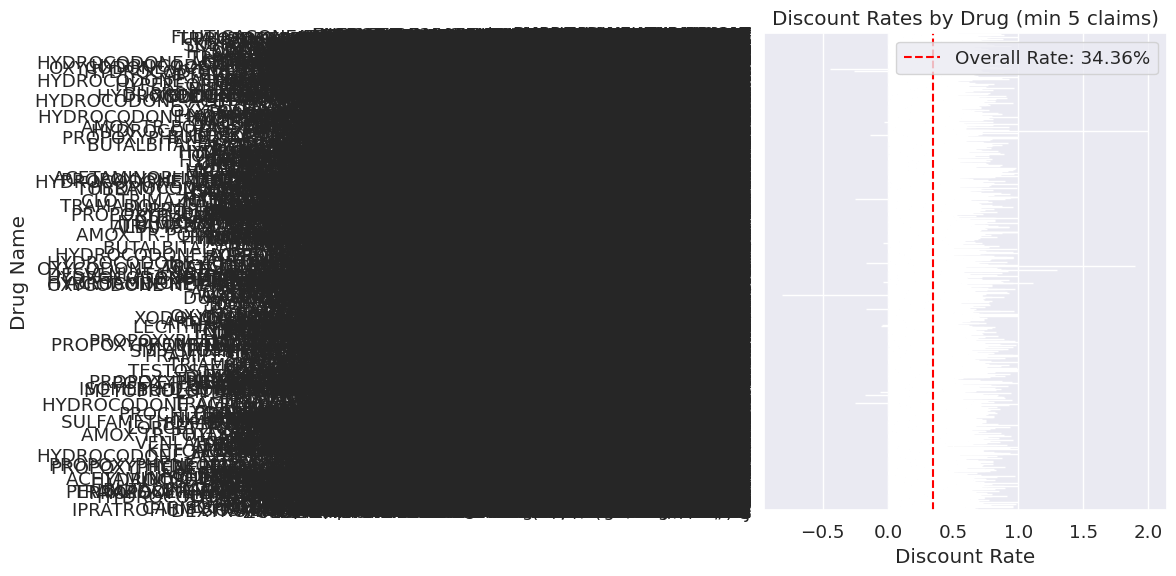

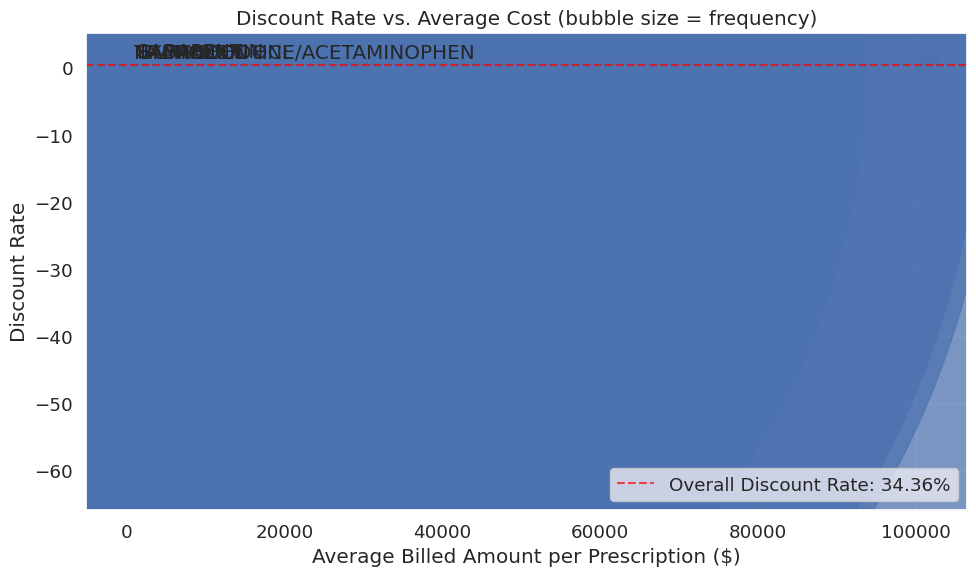

In [ ]:
def analyze_cost_management(detail_data):
    detail_data = detail_data.with_columns([
        pl.col('drugs_supplies_billed_amount').cast(pl.Float64, strict=False),
        pl.col('total_amount_paid_per_line').cast(pl.Float64, strict=False)
    ])
    
    # Calculate overall cost metrics
    total_billed = detail_data.select(pl.sum('drugs_supplies_billed_amount')).item()
    total_paid = detail_data.select(pl.sum('total_amount_paid_per_line')).item()
    discount_rate = 1 - (total_paid / total_billed) if total_billed > 0 else 0
    
    print("Overall Cost Management:")
    print(f"Total Billed Amount: ${total_billed:.2f}")
    print(f"Total Paid Amount: ${total_paid:.2f}")
    print(f"Overall Discount Rate: {discount_rate:.2%}")
    
    # Calculate by drug
    drug_cost = (
        detail_data
        .group_by('drug_name')
        .agg([
            pl.col('drugs_supplies_billed_amount').sum().alias('billed_amount'),
            pl.col('total_amount_paid_per_line').sum().alias('paid_amount'),
            pl.count().alias('count')
        ])
        .with_columns([
            (1 - (pl.col('paid_amount') / pl.col('billed_amount'))).alias('discount_rate'),
            (pl.col('billed_amount') / pl.col('count')).alias('average_billed')
        ])
        .fill_null(0)
    )
    
    # Get drugs with enough data (5+ claims)
    significant_drugs = drug_cost.filter(pl.col('count') >= 5)
    
    if significant_drugs.height > 0:
        best_managed = significant_drugs.sort('discount_rate', descending=True).head(10)
        worst_managed = significant_drugs.sort('discount_rate').head(10)
        
        print("\nDrugs with Best Cost Management (Highest Discount Rate, min 5 claims):")
        print(best_managed.select(['drug_name', 'billed_amount', 'paid_amount', 'discount_rate', 'count']))
        
        print("\nDrugs with Worst Cost Management (Lowest Discount Rate, min 5 claims):")
        print(worst_managed.select(['drug_name', 'billed_amount', 'paid_amount', 'discount_rate', 'count']))
        
        # Convert to pandas for plotting
        significant_drugs_pd = significant_drugs.to_pandas()
        
        plt.figure(figsize=(12, 6))
        sns.barplot(x='discount_rate', y='drug_name', data=significant_drugs_pd)
        plt.title('Discount Rates by Drug (min 5 claims)')
        plt.xlabel('Discount Rate')
        plt.ylabel('Drug Name')
        plt.axvline(x=discount_rate, color='red', linestyle='--', label=f'Overall Rate: {discount_rate:.2%}')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo drugs with 5+ claims for detailed cost management analysis.")
    
    # Convert to pandas for plotting
    drug_cost_pd = drug_cost.to_pandas()
    
    # Plot distribution of discount rates for all drugs
    plt.figure(figsize=(10, 6))
    plt.scatter(drug_cost_pd['average_billed'], drug_cost_pd['discount_rate'], 
                alpha=0.7, s=drug_cost_pd['count']*30)
    
    for _, row in drug_cost_pd.sort_values('count', ascending=False).head(5).iterrows():
        plt.annotate(row['drug_name'], 
                    (row['average_billed'], row['discount_rate']),
                    xytext=(5, 5), textcoords='offset points')
    
    plt.axhline(y=discount_rate, color='red', linestyle='--', alpha=0.7, 
                label=f'Overall Discount Rate: {discount_rate:.2%}')
    plt.xlabel('Average Billed Amount per Prescription ($)')
    plt.ylabel('Discount Rate')
    plt.title('Discount Rate vs. Average Cost (bubble size = frequency)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return drug_cost

cost_data = analyze_cost_management(detail_data)

In [10]:
conn.close()